In [ ]:
import gc
import argparse
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import muspan as ms



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/sarapatti/miniforge3/envs/muspan/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/sarapatti/miniforge3/envs/muspan/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/sarapatti/miniforge3/envs/muspan/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in

In [2]:
# Load the domain inside the worker process
domain = ms.io.load_domain("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/muspan/domains/IPF_RBH_16_muspan_domain.muspan")

MuSpAn domain loaded successfully. Domain summary:
Domain name: IPF_RBH_16
Number of objects: 183019
Collections: ['Cell boundaries', 'Nucleus boundaries', 'Transcripts', 'Cell centroids']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Nucleus Area', 'Transcript ID', 'Cell Type'] 
Networks: ['Delaunay CC', 'Delaunay CC filtered', 'Proximity_30um'] 
Distance matrices: []


In [3]:
np.unique(domain.labels["Cell Type"]["labels"])

array(['AT1 cells', 'AT2 cells', 'Adventitial fibroblasts', 'Aerocytes',
       'Airway/Alveolar macrophages', 'Alveolar fibroblasts', 'B cells',
       'Basal cells', 'Blood endothelial cells - unclassified',
       'CD4+ T cells', 'CD8+ T cells', 'CTHRC1+ fibroblasts',
       'Capillary endothelial cells', 'Ciliated cells', 'Dendritic cells',
       'Goblet cells', 'Interstitial Macrophages',
       'Lipid-associated macrophages', 'Lymphatic endothelial cells',
       'Macrophages', 'Mast cells', 'Monocytes', 'NK cells',
       'Neutrophils', 'Pericytes', 'Plasma cells',
       'Proliferating AT2 cells', 'Proliferating Basal cells',
       'Pulmonary artery endothelial cell',
       'Pulmonary vein endothelial cell', 'SMC',
       'Secretory epithelial cells', 'T cells', 'Unknown'], dtype='<U38')

In [18]:
cell1 = 'Interstitial Macrophages'
cell2 = 'CD8+ T cells'
clusters_of_interest = [cell1, cell2]
# 'Interstitial Macrophages', 'Ciliated cells'
cluster_of_interest_query = ms.query.query(domain, ('label', 'Cell Type'), 'in', clusters_of_interest)

(<Figure size 1000x500 with 2 Axes>, <Axes: >)

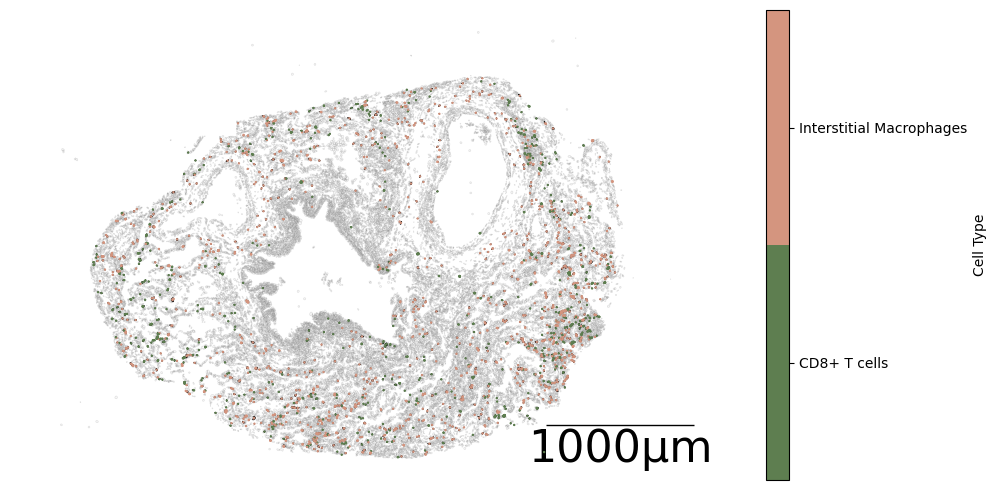

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
# Visualize the domain with cell boundaries
ms.visualise.visualise(
    domain,
    objects_to_plot=('collection', 'Cell boundaries'),
    add_cbar=False,
    shape_kwargs={'alpha': 0.1, 'linewidth': 0.5, 'facecolor': [0.7, 0.7, 0.7, 1]},
    ax=ax
)

ms.visualise.visualise(
    domain,
    objects_to_plot=cluster_of_interest_query,
    color_by='Cell Type',
    ax=ax,
    marker_size=0.5,
    shape_kwargs={'linewidth': 0.4, 'alpha': 1},
                       add_scalebar=True, scalebar_kwargs={'size': 1000, 'label': '1000µm', 'loc': 'lower right', 'pad': 0.1, 'color': 'black', 'frameon': False, 'size_vertical': 2}
)

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

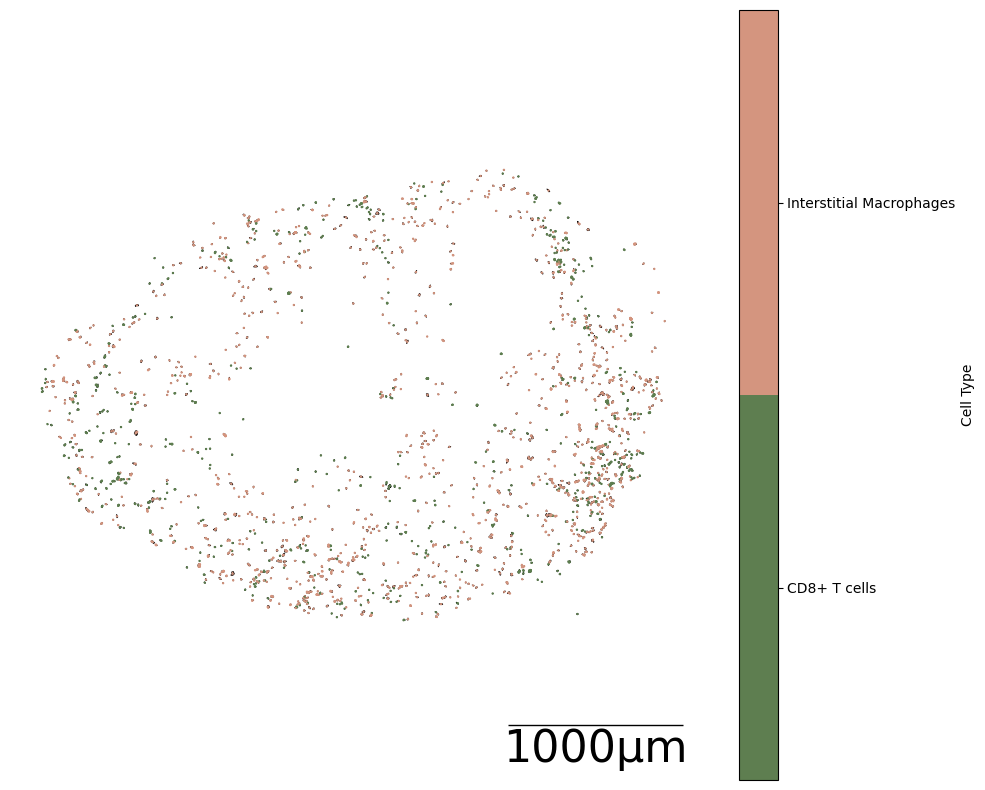

In [20]:
ms.visualise.visualise(
    domain,
    objects_to_plot=cluster_of_interest_query,
    color_by='Cell Type',
    marker_size=0.5,
    shape_kwargs={'linewidth': 0.4, 'alpha': 1},
                       add_scalebar=True, scalebar_kwargs={'size': 1000, 'label': '1000µm', 'loc': 'lower right', 'pad': 0.1, 'color': 'black', 'frameon': False, 'size_vertical': 2}
)

# TCM

In [21]:
# compute and visualise the topographical correlation map between points '
TCM_array = ms.spatial_statistics.topographical_correlation_map(domain,
                                                                population_A=('Cell Type', cell1),
                                                                population_B=('Cell Type', cell2),
                                                                mesh_step=5,
                                                                radius_of_interest=50,
                                                                kernel_radius=150,
                                                                kernel_sigma=30,
                                                                visualise_output=False)

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

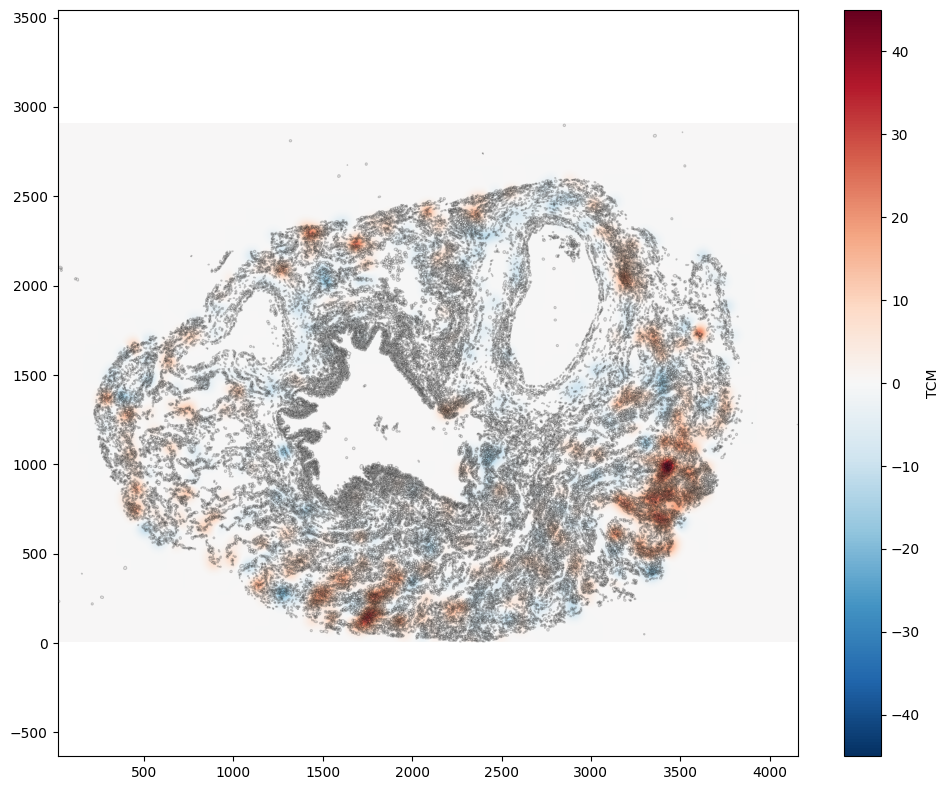

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))
# Visualize the domain with cell boundaries
ms.visualise.visualise(
    domain,
    objects_to_plot=('collection', 'Cell boundaries'),
    add_cbar=False,
    shape_kwargs={'alpha': 0.2, 'linewidth': 0.75, 'facecolor': [0.7, 0.7, 0.7, 1]},
    ax=ax
)

ms.visualise.visualise_topographical_correlation_map(
    domain, 
    TCM_array, 
    ax=ax,
    colorbar_limit=None, 
    tcm_cmap='RdBu_r', 
    colorbar_label='TCM', 
    )

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

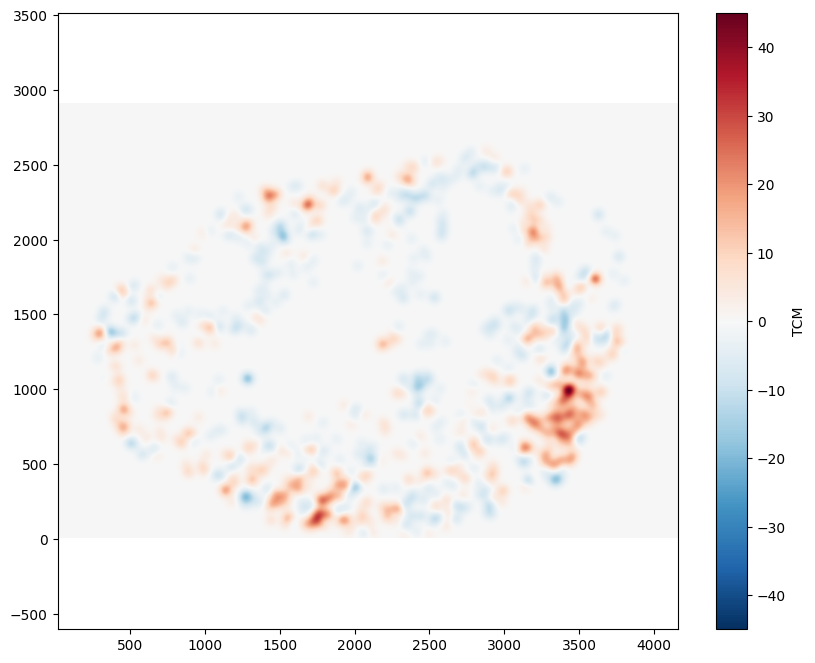

In [23]:

ms.visualise.visualise_topographical_correlation_map(
    domain, 
    TCM_array, 
    colorbar_limit=None, 
    tcm_cmap='RdBu_r', 
    colorbar_label='TCM', 
    )

# HOTSPOT

In [ ]:
# Calculate Moran's I for the specified cell type and region collection
celltype_of_interest = 'Alveolar/Airway Macrophage'

In [ ]:
local_getis_ord_zscore, local_getis_ord_pvals, object_indices = ms.spatial_statistics.getis_ord(
    domain,
    population=('Collection','Cell centroids'),label_name='CD4',
    alpha=0.05,
    network_kwargs={'network_type':'Delaunay','min_edge_distance':0,'max_edge_distance':30},
    add_local_value_as_label=True,
    local_getis_label_name='Local Getis Ord (cells)')


#visualise the Getis-Ord* statistics on the point objects
fig,ax=plt.subplots(figsize=(20,16),nrows=2,ncols=2)
ms.visualise.visualise(domain,color_by=celltype_of_interest,objects_to_plot=('Collection','Cell centroids'),marker_size=5,ax=ax[0,0])
ms.visualise.visualise(domain,color_by="Local Getis Ord (cells)",objects_to_plot=('Collection','Cell centroids'),marker_size=5,ax=ax[0,1])
ms.visualise.visualise(domain,color_by="Local Getis Ord (cells) : p-values (adj)",objects_to_plot=('Collection','Cell centroids'),marker_size=5,ax=ax[1,0])
ms.visualise.visualise(domain,color_by="Local Getis Ord (cells) : significant",objects_to_plot=('Collection','Cell centroids'),marker_size=5,ax=ax[1,1])

gc.collect()